In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve

In [22]:
df = pd.read_csv("application_train.csv")
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
print("Target Distribution:")
print(df['TARGET'].value_counts(normalize=True))

Target Distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [24]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [25]:
# Separate columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numeric columns with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns safely
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()
        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

In [26]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print("Feature shape:", X.shape)

Feature shape: (307511, 120)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic ROC AUC:",
      roc_auc_score(y_test, y_prob_log))

Logistic ROC AUC: 0.745458248063303


In [30]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

cat_model.fit(X_train, y_train)

y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

print("CatBoost ROC AUC:",
      roc_auc_score(y_test, y_prob_cat))

CatBoost ROC AUC: 0.7617834267157948


In [31]:
FP_cost = 1000
FN_cost = 5000

thresholds = np.arange(0.01, 1, 0.01)
costs = []

for t in thresholds:
    y_pred = (y_prob_cat >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = (fp * FP_cost) + (fn * FN_cost)
    costs.append(cost)

best_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

print("Optimal Threshold:", best_threshold)
print("Minimum Business Cost:", min_cost)

Optimal Threshold: 0.16
Minimum Business Cost: 20592000


In [32]:
y_pred_final = (y_prob_cat >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
print("Confusion Matrix:\n", cm)

print("F1 Score:", f1_score(y_test, y_pred_final))
print("ROC AUC:", roc_auc_score(y_test, y_prob_cat))

Confusion Matrix:
 [[50996  5542]
 [ 3010  1955]]
F1 Score: 0.31375381158722515
ROC AUC: 0.7617834267157948


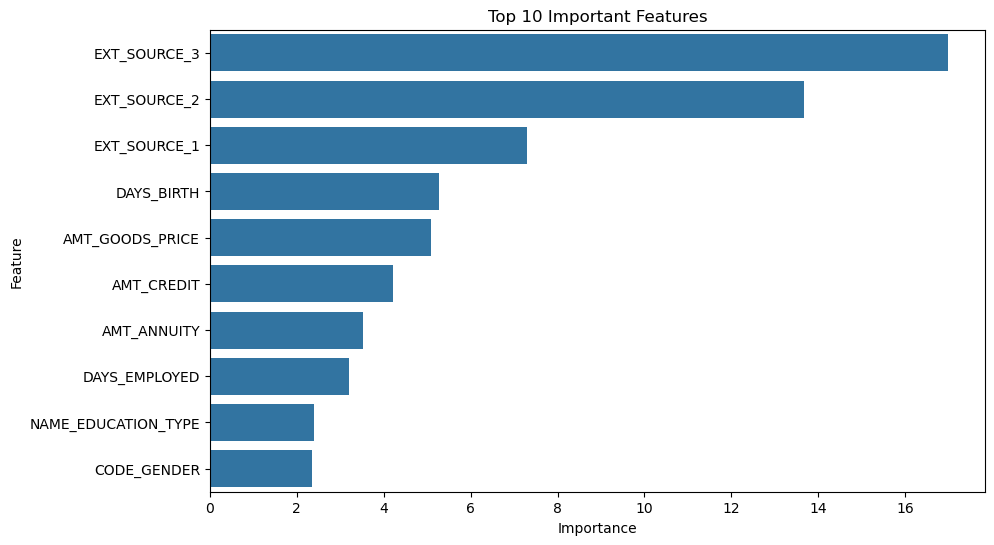

In [33]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance.head(10))
plt.title("Top 10 Important Features")
plt.show()